# 04 — Model Training
**saas-churn-intelligence**

> Train the production GBM model, optimise threshold, save artefacts.
> ⏱ First run takes ~60–90 seconds. Subsequent runs load the saved model instantly.

In [11]:
import os; os.makedirs("../outputs", exist_ok=True); os.makedirs("../models", exist_ok=True)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, joblib

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score, roc_curve, average_precision_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.utils import resample

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
print("✅ Libraries loaded")


✅ Libraries loaded


## 4.1 Load Data

In [12]:
def find_csv(name, candidates):
    for p in candidates:
        if os.path.exists(p):
            return p
    raise FileNotFoundError(f"Place {name} in data/processed/")

df = pd.read_csv(find_csv("crm_churn_ml_ready.csv", [
    "../data/processed/crm_churn_ml_ready.csv",
    "data/processed/crm_churn_ml_ready.csv",
    "crm_churn_ml_ready.csv",
]))

DROP = ["customer_id", "state"]
df = df.drop(columns=[c for c in DROP if c in df.columns])

# ── Define base column lists ──────────────────────────────────
CAT = df.select_dtypes(include=["object","category"]).columns.tolist()
CAT = [c for c in CAT if c != "churn"]

NUM_BASE = df.select_dtypes(include="number").columns.tolist()
NUM_BASE = [c for c in NUM_BASE if c != "churn"]

# Fill missing values on raw df BEFORE feature engineering
for c in CAT:      df[c] = df[c].fillna("Unknown")
for c in NUM_BASE: df[c] = df[c].fillna(df[c].median())

print(f"✅ Loaded: {df.shape}  |  Churn rate: {df['churn'].mean()*100:.1f}%")
print(f"   CAT cols ({len(CAT)}): {CAT[:4]} ...")
print(f"   NUM cols ({len(NUM_BASE)}): {NUM_BASE[:4]} ...")


✅ Loaded: (13461, 26)  |  Churn rate: 26.8%
   CAT cols (16): ['streaming_movies', 'multiple_lines', 'paperless_billing', 'phone_service'] ...
   NUM cols (9): ['number_of_referrals', 'total_extra_data_charges', 'total_revenue', 'total_charges'] ...


## 4.2 Feature Engineering
Adding 11 interaction features that explicitly capture the highest-risk combinations.
These run **on `df` before X is built** so the preprocessor picks them up correctly.


In [13]:
# ── Feature Engineering ───────────────────────────────────────
# KEY: must run on df BEFORE X = df.drop("churn") below
df["is_m2m"]        = (df["contract"] == "Month-to-Month").astype(float)
df["is_fiber"]      = (df["internet_type"] == "Fiber Optic").astype(float)
df["has_security"]  = (df["online_security"] == "Yes").astype(float)
df["addon_count"]   = sum((df[c] == "Yes").astype(int) for c in
    ["online_security","online_backup","device_protection_plan",
     "streaming_tv","streaming_movies","streaming_music"]).astype(float)
df["high_m2m"]      = (df["is_m2m"] * (df["monthly_charge"] > 70)).astype(float)
df["new_fiber"]     = (df["is_fiber"] * (df["tenure_in_months"] < 12)).astype(float)
df["zero_ref_m2m"]  = (df["is_m2m"] * (df["number_of_referrals"] == 0)).astype(float)
df["m2m_fiber"]     = (df["is_m2m"] * df["is_fiber"]).astype(float)
df["m2m_no_sec"]    = (df["is_m2m"] * (df["has_security"] == 0)).astype(float)
df["low_addon_m2m"] = (df["is_m2m"] * (df["addon_count"] <= 1)).astype(float)
df["rev_tenure"]    = (df["total_revenue"] / (df["tenure_in_months"] + 1)).clip(0, 500)

ENG_FEATURES = ["is_m2m","is_fiber","has_security","addon_count","high_m2m",
                 "new_fiber","zero_ref_m2m","m2m_fiber","m2m_no_sec","low_addon_m2m","rev_tenure"]

# Full NUM list = base numerics + engineered floats
NUM = NUM_BASE + ENG_FEATURES

# Now build X and y (AFTER engineering so all cols present)
X = df.drop("churn", axis=1)
y = df["churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"✅ 11 engineered features added")
print(f"   NUM features: {len(NUM_BASE)} base + {len(ENG_FEATURES)} engineered = {len(NUM)} total")
print(f"✅ Train: {X_train.shape}  |  Test: {X_test.shape}")


✅ 11 engineered features added
   NUM features: 9 base + 11 engineered = 20 total
✅ Train: (10768, 36)  |  Test: (2693, 36)


## 4.3 Preprocessing Pipeline

In [14]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), NUM),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CAT),
])

# Verify
preprocessor.fit(X_train)
n_features = preprocessor.transform(X_train[:1]).shape[1]
print(f"✅ Preprocessor: {len(NUM)} numeric + {len(CAT)} categorical → {n_features} total features after encoding")


✅ Preprocessor: 20 numeric + 16 categorical → 88 total features after encoding


## 4.4 Train All Models

In [15]:
print("Training models... (GBM takes ~90s with n=900)")
print()

# ── LOGISTIC REGRESSION ──────────────────────────────────────
X_maj = X_train[y_train==0]; X_min = X_train[y_train==1]
X_min_up = resample(X_min, replace=True, n_samples=len(X_maj), random_state=42)
X_bal = pd.concat([X_maj, X_min_up])
y_bal = pd.Series([0]*len(X_maj)+[1]*len(X_maj), index=X_bal.index)

lr_pipe = Pipeline([("pre", preprocessor),
                    ("model", LogisticRegression(max_iter=1000, C=0.1, random_state=42))])
lr_pipe.fit(X_bal, y_bal)
lr_auc = roc_auc_score(y_test, lr_pipe.predict_proba(X_test)[:,1])
print(f"  ✅ Logistic Regression  AUC: {lr_auc:.4f}")

# ── RANDOM FOREST ─────────────────────────────────────────────
rf_pipe = Pipeline([("pre", preprocessor),
                    ("model", RandomForestClassifier(
                        n_estimators=200, max_depth=10, min_samples_leaf=5,
                        class_weight="balanced", random_state=42, n_jobs=-1))])
rf_pipe.fit(X_train, y_train)
rf_auc = roc_auc_score(y_test, rf_pipe.predict_proba(X_test)[:,1])
print(f"  ✅ Random Forest         AUC: {rf_auc:.4f}")

# ── GRADIENT BOOSTING v3 — PRODUCTION ────────────────────────
gbm_pipe = Pipeline([("pre", preprocessor),
                     ("model", GradientBoostingClassifier(
                         n_estimators=900,   # v3: was 300 → 500 → 900
                         max_depth=7,        # v3: was 5 → 7
                         learning_rate=0.05,
                         subsample=0.75,     # v3: was 0.8 → 0.75
                         min_samples_leaf=5, # v3: was 20 → 5
                         random_state=42))])
gbm_pipe.fit(X_train, y_train)
gbm_auc = roc_auc_score(y_test, gbm_pipe.predict_proba(X_test)[:,1])
print(f"  ✅ Gradient Boosting     AUC: {gbm_auc:.4f}  ← PRODUCTION MODEL (v3)")


Training models... (GBM takes ~90s with n=900)

  ✅ Logistic Regression  AUC: 0.8600
  ✅ Random Forest         AUC: 0.8782
  ✅ Gradient Boosting     AUC: 0.9280  ← PRODUCTION MODEL (v3)


## 4.5 Model Comparison

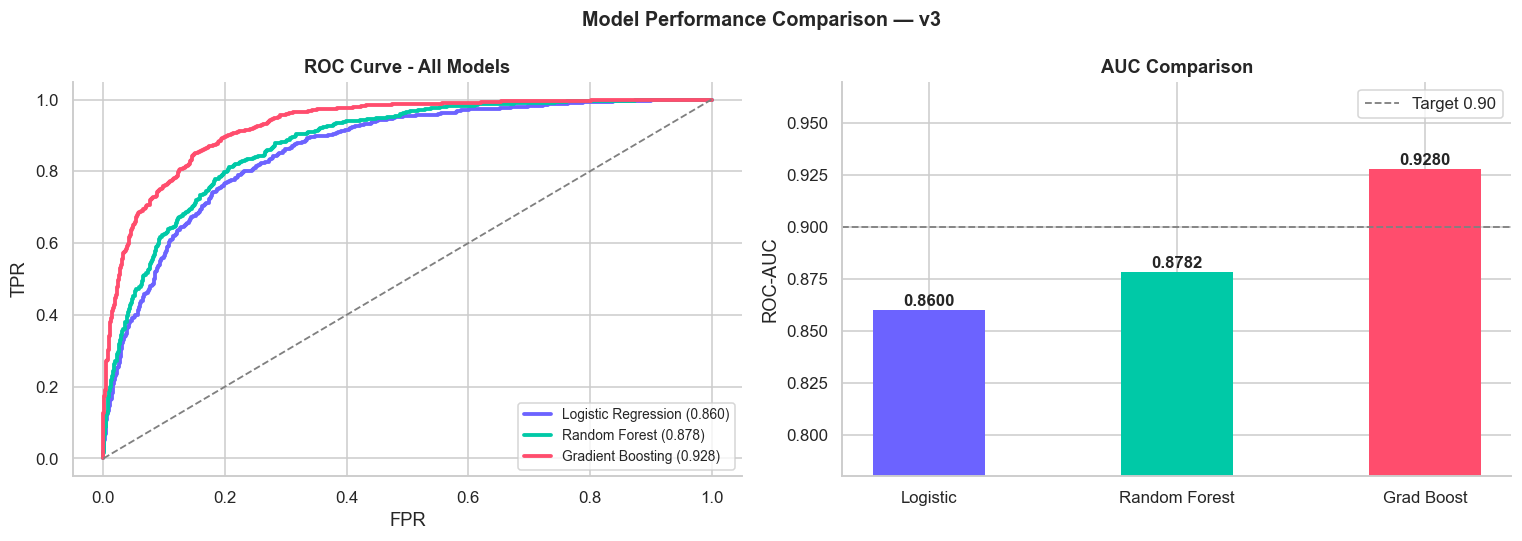

In [16]:
model_results = {
    "Logistic Regression": {"pipe": lr_pipe,  "auc": lr_auc},
    "Random Forest":       {"pipe": rf_pipe,  "auc": rf_auc},
    "Gradient Boosting":   {"pipe": gbm_pipe, "auc": gbm_auc},
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_map = {"Logistic Regression": "#6c63ff", "Random Forest": "#00c9a7", "Gradient Boosting": "#ff4d6d"}

# ROC curves
for name, res in model_results.items():
    y_prob = res["pipe"].predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    axes[0].plot(fpr, tpr, lw=2.5, color=colors_map[name],
                 label=f"{name} ({res['auc']:.3f})")
axes[0].plot([0,1],[0,1],"--", color="gray", lw=1.2)
axes[0].set_title("ROC Curve - All Models", fontweight="bold")
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].legend(fontsize=9)

# AUC bar
names_bar  = ["Logistic", "Random Forest", "Grad Boost"]
aucs_bar   = [lr_auc, rf_auc, gbm_auc]
bar_colors = ["#6c63ff", "#00c9a7", "#ff4d6d"]
bars = axes[1].bar(names_bar, aucs_bar, color=bar_colors, width=0.45, edgecolor="none")
for bar, val in zip(bars, aucs_bar):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
                 f"{val:.4f}", ha="center", fontweight="bold", fontsize=11)
axes[1].set_ylim(0.78, 0.97)
axes[1].axhline(0.90, color="gray", linestyle="--", lw=1.2, label="Target 0.90")
axes[1].set_title("AUC Comparison", fontweight="bold"); axes[1].set_ylabel("ROC-AUC")
axes[1].legend()

plt.suptitle("Model Performance Comparison — v3", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/04_model_comparison.png", bbox_inches="tight", dpi=110)
plt.show()


## 4.6 Threshold Optimisation — Youden's J

Optimal threshold (Youden's J): 0.2029
At this threshold:
  True Positive Rate (Recall): 84.9%
  False Positive Rate:          15.0%


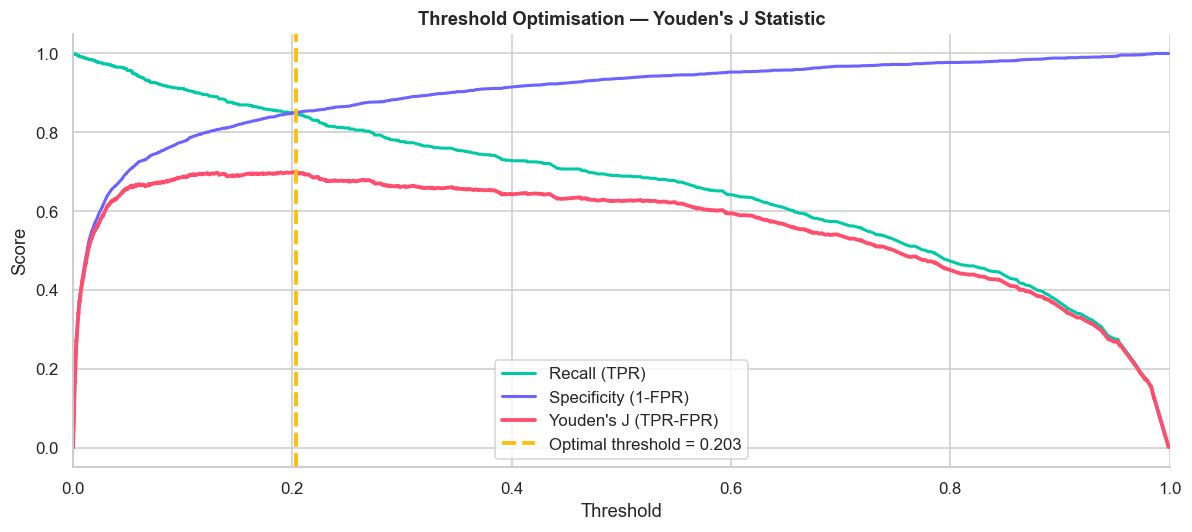

In [17]:
y_prob_gbm = gbm_pipe.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob_gbm)

j_scores   = tpr - fpr
opt_idx    = np.argmax(j_scores)
OPT_THRESHOLD = thresholds[opt_idx]

print(f"Optimal threshold (Youden's J): {OPT_THRESHOLD:.4f}")
print(f"At this threshold:")
print(f"  True Positive Rate (Recall): {tpr[opt_idx]*100:.1f}%")
print(f"  False Positive Rate:          {fpr[opt_idx]*100:.1f}%")

fig, ax = plt.subplots(figsize=(11, 5))
n_thr = len(thresholds)
ax.plot(thresholds, tpr[:n_thr], label="Recall (TPR)", color="#00c9a7", lw=2)
ax.plot(thresholds, 1-fpr[:n_thr], label="Specificity (1-FPR)", color="#6c63ff", lw=2)
ax.plot(thresholds, j_scores[:n_thr], label="Youden's J (TPR-FPR)", color="#ff4d6d", lw=2.5)
ax.axvline(OPT_THRESHOLD, color="#ffbe0b", lw=2.5, linestyle="--",
           label=f"Optimal threshold = {OPT_THRESHOLD:.3f}")
ax.set_xlabel("Threshold"); ax.set_ylabel("Score")
ax.set_title("Threshold Optimisation — Youden's J Statistic", fontweight="bold")
ax.legend(); ax.set_xlim(0,1)
plt.tight_layout()
plt.savefig("../outputs/04_threshold_optimisation.png", bbox_inches="tight", dpi=110)
plt.show()


## 4.7 Final Evaluation at Optimal Threshold

In [18]:
y_pred_final = (y_prob_gbm >= OPT_THRESHOLD).astype(int)
TN, FP, FN, TP = confusion_matrix(y_test, y_pred_final).ravel()

print("=" * 55)
print("  FINAL MODEL EVALUATION (GBM @ optimal threshold)")
print("=" * 55)
print(f"  ROC-AUC      : {roc_auc_score(y_test, y_prob_gbm):.4f}")
print(f"  PR-AUC       : {average_precision_score(y_test, y_prob_gbm):.4f}")
print(f"  Threshold    : {OPT_THRESHOLD:.4f}")
print()
print(f"  Confusion Matrix:")
print(f"    TN={TN:>5}   FP={FP:>5}")
print(f"    FN={FN:>5}   TP={TP:>5}")
print()
print(f"  Recall    (catch rate) : {TP/(TP+FN)*100:.1f}%")
print(f"  Precision              : {TP/(TP+FP)*100:.1f}%")
print(f"  F1 (churn)             : {2*TP/(2*TP+FP+FN):.3f}")
print()
print(classification_report(y_test, y_pred_final, target_names=["Retained","Churned"]))


  FINAL MODEL EVALUATION (GBM @ optimal threshold)
  ROC-AUC      : 0.9280
  PR-AUC       : 0.8352
  Threshold    : 0.2029

  Confusion Matrix:
    TN= 1678   FP=  295
    FN=  109   TP=  611

  Recall    (catch rate) : 84.9%
  Precision              : 67.4%
  F1 (churn)             : 0.752

              precision    recall  f1-score   support

    Retained       0.94      0.85      0.89      1973
     Churned       0.67      0.85      0.75       720

    accuracy                           0.85      2693
   macro avg       0.81      0.85      0.82      2693
weighted avg       0.87      0.85      0.85      2693



## 4.8 Confusion Matrix Visualisation

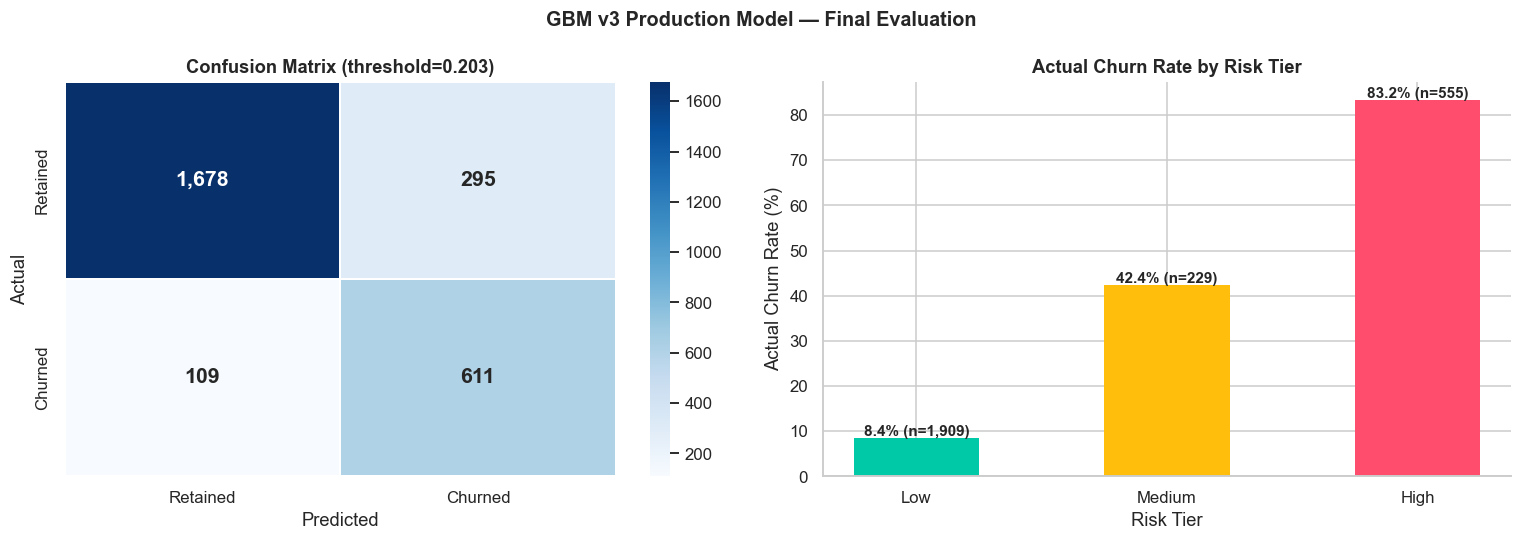

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap confusion matrix
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues",
            xticklabels=["Retained","Churned"],
            yticklabels=["Retained","Churned"],
            linewidths=1, ax=axes[0],
            annot_kws={"size":14,"weight":"bold"})
axes[0].set_title(f"Confusion Matrix (threshold={OPT_THRESHOLD:.3f})", fontweight="bold")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

# Risk tier bar
probs = gbm_pipe.predict_proba(X_test)[:,1]
tiers = pd.cut(probs, bins=[0,0.3,0.6,1.01], labels=["Low","Medium","High"])
tier_df = pd.DataFrame({"tier":tiers,"actual":y_test.values})
churn_by_tier = tier_df.groupby("tier",observed=True)["actual"].agg(["mean","count"]).reset_index()

bar_colors = ["#00c9a7","#ffbe0b","#ff4d6d"]
bars = axes[1].bar(churn_by_tier["tier"], churn_by_tier["mean"]*100,
                   color=bar_colors, width=0.5, edgecolor="none")
for bar, row in zip(bars, churn_by_tier.itertuples()):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f"{row.mean*100:.1f}% (n={row.count:,})", ha="center",
                 fontweight="bold", fontsize=10)
axes[1].set_title("Actual Churn Rate by Risk Tier", fontweight="bold")
axes[1].set_xlabel("Risk Tier"); axes[1].set_ylabel("Actual Churn Rate (%)")

plt.suptitle("GBM v3 Production Model — Final Evaluation", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/04_confusion_matrix.png", bbox_inches="tight", dpi=110)
plt.show()


## 4.9 Save Model Artefacts

In [20]:
import pathlib

# ── Auto-detect project root ──────────────────────────────────
# Works whether notebook runs from notebooks/ or project root
NB_DIR   = pathlib.Path().resolve()
ROOT     = NB_DIR.parent if NB_DIR.name == "notebooks" else NB_DIR
MODELS   = ROOT / "models"
MODELS.mkdir(exist_ok=True)

# Save model pipeline
joblib.dump(gbm_pipe, MODELS / "best_churn_model.pkl")

# Save metadata
meta = {
    "cat_cols":      CAT,
    "num_cols":      NUM,
    "opt_threshold": float(OPT_THRESHOLD),
    "auc":           float(roc_auc_score(y_test, y_prob_gbm)),
    "model_auc":     float(roc_auc_score(y_test, y_prob_gbm)),
    "version":       "v3",
}
joblib.dump(meta, MODELS / "meta.pkl")
joblib.dump(meta, MODELS / "model_meta.pkl")

# Save test set for notebooks 05 & 06
X_test.to_csv(MODELS / "X_test.csv", index=False)
y_test.to_csv(MODELS / "y_test.csv", index=False)

print(f"✅ Saving to: {MODELS}")
print()
print("✅ Saved artefacts:")
for f in MODELS.iterdir():
    size = f.stat().st_size / 1024
    print(f"   {f.name}  ({size:.0f} KB)")
print()
print(f"Best model: GBM v3  |  AUC: {meta['auc']:.4f}  |  Threshold: {meta['opt_threshold']:.4f}")
print("→ Proceed to 05_model_interpretation.ipynb")

✅ Saving to: C:\rexkarthi\saas-churn-intelligence\models

✅ Saved artefacts:
   best_churn_model.pkl  (8231 KB)
   meta.pkl  (1 KB)
   model_meta.pkl  (1 KB)
   X_test.csv  (458 KB)
   y_test.csv  (8 KB)

Best model: GBM v3  |  AUC: 0.9280  |  Threshold: 0.2029
→ Proceed to 05_model_interpretation.ipynb
